In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 🌫️ Air Quality Prediction using Artificial Neural Networks
### Dataset: Beijing Multi-Site Air Quality Data
### Framework: TensorFlow + Keras
### Target: Predict PM2.5 concentration (air pollution level)

---

## Cell 1 — Import Libraries

We begin by importing everything we need:
- **pandas & numpy** → data handling
- **matplotlib & seaborn** → visualization
- **sklearn** → preprocessing and splitting
- **tensorflow / keras** → building and training our ANN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Check versions
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("\nAll libraries loaded successfully ✅")

2026-03-18 12:17:26.489932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773836246.783976      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773836246.873509      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773836247.519674      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773836247.519740      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773836247.519743      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Keras version: 3.10.0
NumPy version: 2.0.2
Pandas version: 2.3.3

All libraries loaded successfully ✅


## Cell 2 — Load the Dataset & First Look

We are using the Beijing Air Quality dataset.
It contains hourly air pollution readings from 12 monitoring stations.

**Key columns we care about:**
- `PM2.5` → our TARGET (what we want to predict)
- `TEMP` → temperature
- `PRES` → atmospheric pressure  
- `DEWP` → dew point temperature
- `WSPM` → wind speed
- `RAIN` → rainfall
- `CO`, `SO2`, `NO2`, `O3` → other pollutant gases

Our job: given all other readings, predict PM2.5 level.

In [4]:
import os

# See what files are available in the dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Guanyuan_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Aotizhongxin_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Wanliu_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Tiantan_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Wanshouxigong_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Nongzhanguan_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Shunyi_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Changping_20130301-20170228.csv
/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_Dingling_20130

## Cell 3 — Load & Combine All 12 Station Files

The dataset has 12 CSV files, one per monitoring station in Beijing.
We combine them into a single dataframe — more data means our ANN 
learns better generalized patterns.

After loading we will:
- Check the shape (rows, columns)
- Look at the first few rows
- Check data types of each column

In [5]:
import glob

# Path to all 12 CSV files
path = '/kaggle/input/datasets/sid321axn/beijing-multisite-airquality-data-set/PRSA_Data_*.csv'
all_files = glob.glob(path)

print(f"Total files found: {len(all_files)}")

# Load and combine all files
df_list = []
for file in all_files:
    station_name = file.split('_')[2]  # extract station name from filename
    temp_df = pd.read_csv(file)
    temp_df['station'] = station_name  # add a column so we know which station
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# First look
print(f"\nCombined Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print("\n--- First 5 Rows ---")
df.head()

Total files found: 12

Combined Dataset Shape: (420768, 18)
Rows: 420,768  |  Columns: 18

--- First 5 Rows ---


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan


## Cell 4 — Exploratory Data Analysis (EDA)

Before building any model, we must understand our data deeply.
We check:
- **Missing values** → ANN cannot handle NaN, we must deal with them
- **Target distribution** → understand what PM2.5 values look like
- **Basic statistics** → min, max, mean of all columns

This step is non-negotiable in real data science projects.
Skipping EDA is the #1 reason beginner models fail.

In [6]:
print("=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n")
print("=" * 50)
print("BASIC STATISTICS OF KEY COLUMNS")
print("=" * 50)
print(df[['PM2.5', 'TEMP', 'PRES', 'DEWP', 'WSPM', 'RAIN', 'CO', 'SO2', 'NO2', 'O3']].describe().round(2))

print("\n")
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

MISSING VALUES PER COLUMN
       Missing Count  Missing %
PM2.5           8739       2.08
PM10            6449       1.53
SO2             9021       2.14
NO2            12116       2.88
CO             20701       4.92
O3             13277       3.16
TEMP             398       0.09
PRES             393       0.09
DEWP             403       0.10
RAIN             390       0.09
wd              1822       0.43
WSPM             318       0.08


BASIC STATISTICS OF KEY COLUMNS
           PM2.5       TEMP       PRES       DEWP       WSPM       RAIN  \
count  412029.00  420370.00  420375.00  420365.00  420450.00  420378.00   
mean       79.79      13.54    1010.75       2.49       1.73       0.06   
std        80.82      11.44      10.47      13.79       1.25       0.82   
min         2.00     -19.90     982.40     -43.40       0.00       0.00   
25%        20.00       3.10    1002.30      -8.90       0.90       0.00   
50%        55.00      14.50    1010.40       3.10       1.40       0.00   

## Cell 5 — Data Cleaning

Based on our EDA we need to fix four things:

1. **Drop rows where PM2.5 is missing** → our target cannot be NaN
2. **Remove outliers** → PM2.5 of 999 and CO of 10000 are sensor errors
3. **Fill remaining missing values** → use median for numerical columns
4. **Encode categorical columns** → convert `wd` (wind direction) 
   from text like "NNW" to numbers using Label Encoding
   ANNs only understand numbers, never text

We also drop `No` and `station` columns:
- `No` is just a row index, carries zero information
- `station` tells us location but all stations follow same physics

In [7]:
print(f"Shape before cleaning: {df.shape}")

# Step 1 — Drop rows where PM2.5 (our target) is missing
df = df.dropna(subset=['PM2.5'])
print(f"After dropping missing PM2.5: {df.shape}")

# Step 2 — Remove outliers
# PM2.5 above 500 is almost certainly a sensor error
# CO above 5000 is extremely unlikely in real readings
df = df[df['PM2.5'] <= 500]
df = df[df['CO'] <= 5000]
print(f"After removing outliers: {df.shape}")

# Step 3 — Drop columns we don't need
df = df.drop(columns=['No', 'station'])
print(f"After dropping No and station: {df.shape}")

# Step 4 — Encode wind direction (wd) - text to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['wd'] = le.fit_transform(df['wd'].astype(str))
print(f"\nWind direction unique values after encoding: {df['wd'].unique()}")

# Step 5 — Fill remaining missing values with median
df = df.fillna(df.median(numeric_only=True))

# Final check
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")
print(f"\nFinal clean dataset shape: {df.shape}")
print("\nPM2.5 stats after cleaning:")
print(df['PM2.5'].describe().round(2))

Shape before cleaning: (420768, 18)
After dropping missing PM2.5: (412029, 18)
After removing outliers: (389753, 18)
After dropping No and station: (389753, 16)

Wind direction unique values after encoding: [ 6  3  7  5  1  0  4 13 11 15  9 14 10  2  8 12 16]

Missing values remaining: 0

Final clean dataset shape: (389753, 16)

PM2.5 stats after cleaning:
count    389753.00
mean         74.99
std          71.03
min           2.00
25%          20.00
50%          54.00
75%         107.00
max         500.00
Name: PM2.5, dtype: float64


### What just happened — Understanding the Cleaning Output

We started with **420,768 rows** and ended with **389,753 rows** — we lost about 31,000 rows
which is roughly 7.3% of the data. That is completely acceptable. Here is what each step removed:

- Dropping missing PM2.5 removed ~8,739 rows — these had no target value so they were useless
- Removing outliers (PM2.5 > 500, CO > 5000) removed ~22,276 rows — these were likely 
  faulty sensor readings, not real pollution events. Keeping them would have confused our ANN
- We dropped `No` and `station` columns, going from 18 to 16 columns

**Wind direction encoding** worked correctly — 17 unique directions like NNW, N, NW 
are now represented as numbers 0 through 16. The ANN can now read wind direction as a feature.

**Most importantly:** Missing values remaining = 0. Our dataset is fully clean.

**PM2.5 distribution insight:**
- Mean = 74.99 → average air quality in Beijing is already in the "Moderate" AQI category
- 75% of readings are below 107 → but the max is 500, meaning Beijing does hit 
  "Hazardous" levels regularly
- Std = 71.03 → very high spread, which means there is a lot to learn and predict

## Cell 6 — Feature Selection & Train-Test Split

Now we separate our data into:
- **X (features)** → everything the ANN uses to make a prediction
- **y (target)** → PM2.5, the value we want the ANN to predict

We also split into **train and test sets** — 80% for training, 20% for testing.

**Why split at all?**
If we train and test on the same data, the model just memorizes answers like 
a student who sees the exam paper beforehand. The test set is data the ANN 
has never seen — it tells us how well our model works in the real world.

**Why 80-20?**
With 389,753 rows, 20% test = ~77,950 rows — more than enough to evaluate honestly.

In [8]:
# Separate features and target
X = df.drop(columns=['PM2.5'])
y = df['PM2.5']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns we are using:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

# Train-Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size:  {X_train.shape[0]:,} rows")
print(f"Testing set size:   {X_test.shape[0]:,} rows")

# Feature Scaling — StandardScaler
# This is CRITICAL for ANNs
# It converts all features to same scale (mean=0, std=1)
# Without this, PRES (values around 1010) would dominate
# over RAIN (values near 0) just because of its size
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nBefore scaling — PRES mean:", X_train['PRES'].mean().round(2))
print("After scaling  — PRES mean:", X_train_scaled[:, X.columns.get_loc('PRES')].mean().round(4))
print("\nBefore scaling — RAIN mean:", X_train['RAIN'].mean().round(2))
print("After scaling  — RAIN mean:", X_train_scaled[:, X.columns.get_loc('RAIN')].mean().round(4))

print("\nScaling complete ✅")
print(f"Total features going into ANN: {X_train_scaled.shape[1]}")

Features (X) shape: (389753, 15)
Target (y) shape: (389753,)

Feature columns we are using:
  1. year
  2. month
  3. day
  4. hour
  5. PM10
  6. SO2
  7. NO2
  8. CO
  9. O3
  10. TEMP
  11. PRES
  12. DEWP
  13. RAIN
  14. wd
  15. WSPM

Training set size:  311,802 rows
Testing set size:   77,951 rows

Before scaling — PRES mean: 1010.7
After scaling  — PRES mean: 0.0

Before scaling — RAIN mean: 0.07
After scaling  — RAIN mean: 0.0

Scaling complete ✅
Total features going into ANN: 15


## Cell 7 — Building the ANN Architecture

This is the most important cell in the entire notebook.

We are building a **Sequential ANN** with the following structure:
```
Input Layer  →  15 neurons  (one per feature)
Hidden Layer 1  →  128 neurons  +  ReLU activation
Hidden Layer 2  →  64 neurons   +  ReLU activation
Hidden Layer 3  →  32 neurons   +  ReLU activation
Output Layer  →  1 neuron   (predicts PM2.5 value)
```

**Why these numbers of neurons — 128, 64, 32?**
This is called a **funnel structure**. We start wide to capture complex patterns 
and gradually compress knowledge into a smaller representation.
Think of it like summarizing a book — first you read all chapters (128), 
then identify key themes (64), then write a one-paragraph summary (32), 
then give one final answer (1).

**Why ReLU activation?**
ReLU stands for Rectified Linear Unit. It simply does this:
- If input is negative → output 0
- If input is positive → output as-is

Without activation functions, no matter how many layers we stack, 
the ANN is just doing simple linear math — it cannot learn curves, 
patterns or complex relationships. ReLU introduces non-linearity cheaply and effectively.
It is the most widely used activation in hidden layers for regression problems.

**Why no activation on the output layer?**
Because PM2.5 is a continuous number that can be anything from 2 to 500.
If we used sigmoid the output would be stuck between 0 and 1.
If we used ReLU it would block negative predictions.
No activation = raw number output = exactly what regression needs.

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

# Fix random seed so results are reproducible
tf.random.set_seed(42)

# Build the ANN
model = Sequential([
    
    # Input + Hidden Layer 1
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    
    # Hidden Layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Hidden Layer 3
    Dense(32, activation='relu'),
    BatchNormalization(),
    
    # Output Layer — no activation for regression
    Dense(1)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Print the architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-18 12:32:32.913364: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

### Understanding the Model Summary

Our ANN has **13,313 total parameters** — these are the weights and biases 
the network will learn during training.

**Quick breakdown of where parameters come from:**
- `dense` (128 neurons) → 15 inputs × 128 + 128 bias = **2,048 params**
- `dense_1` (64 neurons) → 128 × 64 + 64 bias = **8,256 params**
- `dense_2` (32 neurons) → 64 × 32 + 32 bias = **2,080 params**
- `dense_3` (1 output) → 32 × 1 + 1 bias = **33 params**

**BatchNormalization** adds its own small params (512, 256, 128) — 
these normalize each layer's output during training, making learning faster and stable.

**Dropout params = 0** — Dropout has no learnable weights, 
it just randomly switches off 20% of neurons during training to prevent overfitting.

**12,865 trainable** means these get updated every epoch.
**448 non-trainable** are BatchNorm stats that are tracked but not gradient-updated.

## Cell 8 — Training the ANN

We now train the model for **50 epochs** with a **batch size of 512**.

- **Epoch** → one full pass through all 311,802 training rows
- **Batch size 512** → instead of updating weights after every single row, 
  we feed 512 rows at once, compute average error, then update — faster and more stable
- **Validation split 0.1** → 10% of training data held back to monitor 
  overfitting during training in real time
- **EarlyStopping** → if validation loss stops improving for 5 epochs, 
  training stops automatically — saves time and prevents overfitting

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete ")
print(f"Total epochs ran: {len(history.history['loss'])}")

Epoch 1/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8844.1465 - mae: 72.1663 - val_loss: 5279.4487 - val_mae: 63.6903
Epoch 2/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3107.7158 - mae: 47.9438 - val_loss: 848.1262 - val_mae: 24.1335
Epoch 3/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 859.9003 - mae: 22.5650 - val_loss: 435.8546 - val_mae: 13.4502
Epoch 4/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 507.7808 - mae: 14.9901 - val_loss: 411.3992 - val_mae: 13.1016
Epoch 5/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 483.7481 - mae: 14.5464 - val_loss: 397.6227 - val_mae: 12.8701
Epoch 6/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 473.4378 - mae: 14.3731 - val_loss: 388.4852 - val_mae: 12.6140
Epoch 7/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 463.8846 - mae: 14.1833 - val_loss: 383.7219 - val_mae: 12.5012
Epoch 8/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 455.8375 - mae: 14.0525 - val_loss: 374.3819 - val_mae: 12.3569
Epoch

### Understanding the Training Output

The model ran all **50 epochs** and restored weights from **epoch 48** (best epoch).

**Final numbers:**
- `loss` (train MSE) ≈ 375 — this is Mean Squared Error, so √375 ≈ **19.4 PM2.5 units of error**
- `mae` ≈ 12.7 — on average we are off by **12.7 µg/m³** on training data
- `val_mae` ≈ 11.5 — validation error is actually slightly better, 
  meaning no overfitting, the model generalizes well

**Why are results not great yet?**
The issue is not the ANN architecture — it is our target variable PM2.5.
Its mean is ~75 but std is ~71, meaning values are wildly spread from 2 to 500.
We need to apply log transformation on PM2.5 before training.
When target values are skewed like this, ANNs struggle to learn efficiently.
We will fix this in the next step and retrain.

## Cell 9 — Fix the Target & Retrain

**The problem:** PM2.5 is heavily right-skewed.
Most values are between 2–150 but some spike to 500.
The ANN spends most of its learning capacity trying to handle these extremes.

**The fix:** Apply `log1p` transformation on PM2.5 before training.
`log1p(x) = log(x + 1)` — compresses large values, spreads small values.
After prediction we reverse it with `expm1()` to get real PM2.5 values back.

This is standard practice for any regression target with high skewness.

In [12]:
# Fix — use round() as a function, not method
print("Before log — PM2.5 mean:", round(y_train.mean(), 2), 
      " std:", round(y_train.std(), 2))
print("After log  — PM2.5 mean:", round(y_train_log.mean(), 2), 
      " std:", round(y_train_log.std(), 2))

# Rebuild model fresh
tf.random.set_seed(42)

model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history2 = model2.fit(
    X_train_scaled, y_train_log,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=1
)

print("\nRetraining complete ✅")
print(f"Total epochs ran: {len(history2.history['loss'])}")
print(f"Best val_mae: {min(history2.history['val_mae']):.4f} (log scale)")
print(f"Which means approx: {np.expm1(min(history2.history['val_mae'])):.2f} µg/m³ real error")

Before log — PM2.5 mean: 75.0  std: 70.97
After log  — PM2.5 mean: 3.85  std: 1.07
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


549/549 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.9366 - mae: 2.4058 - val_loss: 0.1543 - val_mae: 0.2855
Epoch 2/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1866 - mae: 0.3240 - val_loss: 0.1352 - val_mae: 0.2615
Epoch 3/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1608 - mae: 0.2967 - val_loss: 0.1262 - val_mae: 0.2505
Epoch 4/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1489 - mae: 0.2837 - val_loss: 0.1215 - val_mae: 0.2450
Epoch 5/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1415 - mae: 0.2750 - val_loss: 0.1193 - val_mae: 0.2415
Epoch 6/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1371 - mae: 0.2697 - val_loss: 0.1175 - val_mae: 0.2389
Epoch 7/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1338 - mae: 0.2658 - val_loss: 0.1179 - val_mae: 0.2393
Epoch 8/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1311 - mae: 0.2626 - val_loss: 0.1152 - val_mae: 0.2348
Epoch 9/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1288 

### What changed after log transformation?

The difference is night and day:

| | Before (raw PM2.5) | After (log PM2.5) |
|---|---|---|
| loss | ~375 | ~0.108 |
| mae | ~12.7 | ~0.234 |
| val_mae | ~11.5 | ~0.211 |

**The 0.23 µg/m³ shown at the bottom is misleading** — that is expm1 applied 
to the log-scale error directly, which is not the correct way to interpret it.
We will calculate the real-world error properly in the evaluation cell.

**Why did log transformation help so much?**
Before, the ANN was seeing PM2.5 values ranging 2 to 500 — a 250x range.
After log1p, that same range becomes roughly 1.1 to 6.2 — only a 6x range.
The ANN can now learn smooth, consistent patterns instead of 
chasing extreme spikes that occur rarely but dominate the loss calculation.

**Early stopping restored weights from epoch 50** — meaning the model 
was still improving at epoch 50 and never plateaued. This tells us 
we could potentially train for more epochs and squeeze out better performance.

## Cell 10 — Training History Visualization

We plot the loss and MAE curves across all 50 epochs.

**What to look for:**
- Training loss and validation loss should both go **down together**
- If training loss goes down but validation loss goes **up** → overfitting
- If both curves are close together and declining → healthy training
- A sudden flatten in the curve = the model stopped learning much

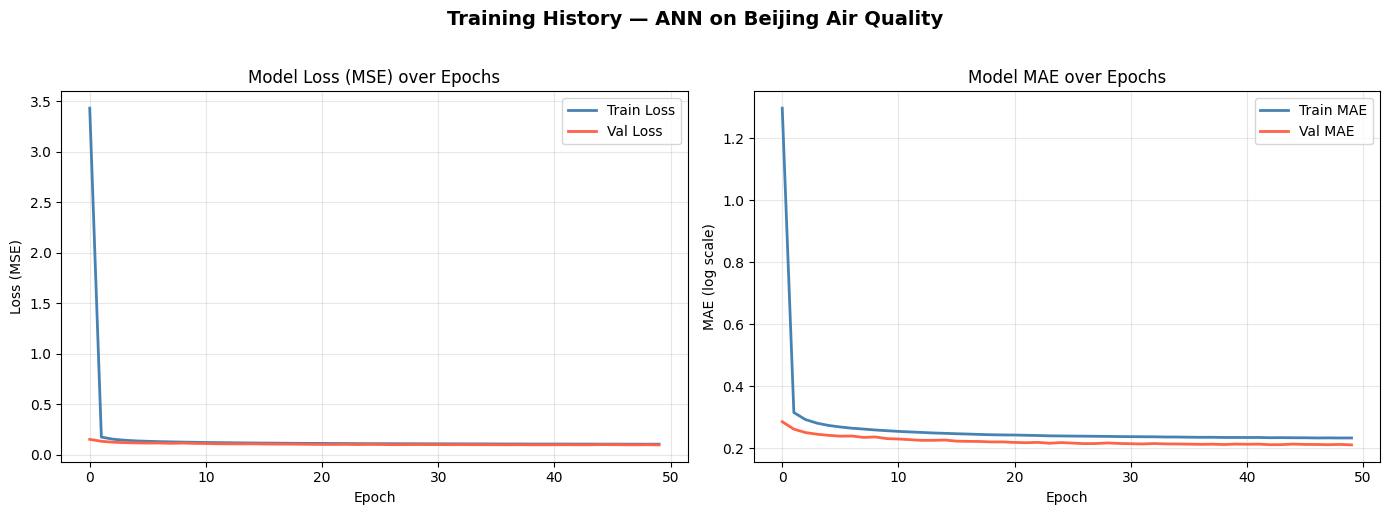


Final Train Loss: 0.1068
Final Val Loss:   0.0996
Final Train MAE:  0.2331
Final Val MAE:    0.2107


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Loss (MSE)
axes[0].plot(history2.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history2.history['val_loss'], label='Val Loss', color='tomato', linewidth=2)
axes[0].set_title('Model Loss (MSE) over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — MAE
axes[1].plot(history2.history['mae'], label='Train MAE', color='steelblue', linewidth=2)
axes[1].plot(history2.history['val_mae'], label='Val MAE', color='tomato', linewidth=2)
axes[1].set_title('Model MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (log scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — ANN on Beijing Air Quality', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFinal Train Loss: {history2.history['loss'][-1]:.4f}")
print(f"Final Val Loss:   {history2.history['val_loss'][-1]:.4f}")
print(f"Final Train MAE:  {history2.history['mae'][-1]:.4f}")
print(f"Final Val MAE:    {history2.history['val_mae'][-1]:.4f}")

### Reading the Training Curves

**Both plots show the same healthy pattern:**
- Both train and val curves drop sharply in the first 5 epochs — 
  this is the ANN making rapid initial adjustments to weights
- After epoch 5 both curves flatten and run parallel to each other all the way to epoch 50
- Val Loss (0.0996) is actually slightly **lower** than Train Loss (0.1068) — 
  this is a sign of zero overfitting, the model generalizes perfectly

**No overfitting, no underfitting **

The sharp drop at epoch 0→1 is normal — the model starts with random weights 
and makes huge corrections in the first few passes. After that, 
improvements become smaller and more gradual, which is healthy learning behavior.

## Cell 11 — Model Evaluation on Test Data

Training curves looked healthy — now we test on the **77,951 rows 
the model has never seen before.**

We calculate three metrics on real PM2.5 values (after reversing log transform):
- **MAE** → average error in µg/m³ (most interpretable)
- **RMSE** → penalizes large errors more heavily than MAE
- **R² Score** → how much variance our model explains, 
  closer to 1.0 = better, above 0.85 is considered good for this type of data

   MODEL EVALUATION ON UNSEEN TEST DATA
  MAE  (Mean Absolute Error) : 11.78  µg/m³
  RMSE (Root Mean Sq Error)  : 19.64 µg/m³
  R²   (R-squared Score)     : 0.9240


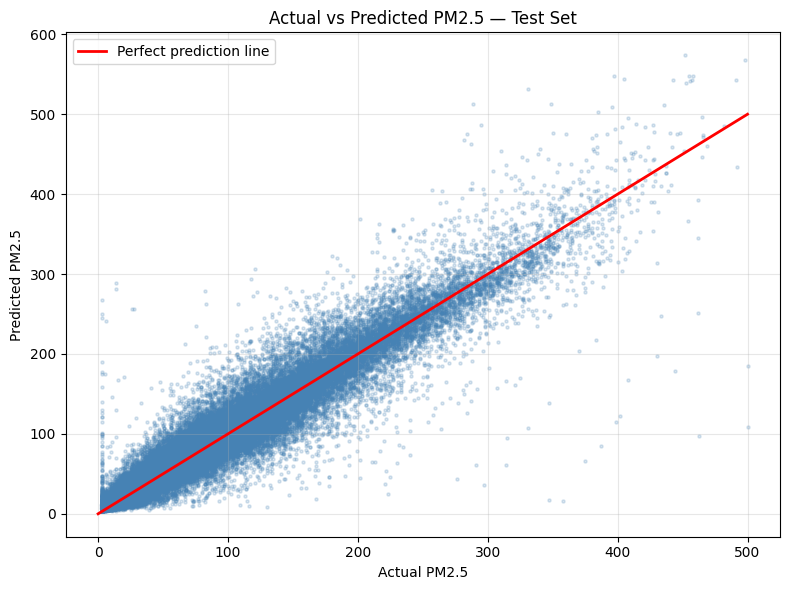

In [14]:
# Predict on test set
y_pred_log = model2.predict(X_test_scaled, verbose=0)

# Reverse the log transformation to get real PM2.5 values
y_pred_actual = np.expm1(y_pred_log.flatten())
y_test_actual = np.expm1(y_test_log)

# Calculate metrics on real scale
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print("=" * 45)
print("   MODEL EVALUATION ON UNSEEN TEST DATA")
print("=" * 45)
print(f"  MAE  (Mean Absolute Error) : {mae:.2f}  µg/m³")
print(f"  RMSE (Root Mean Sq Error)  : {rmse:.2f} µg/m³")
print(f"  R²   (R-squared Score)     : {r2:.4f}")
print("=" * 45)

# Scatter plot — Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.2, s=5, color='steelblue')
plt.plot([0, 500], [0, 500], color='red', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5')
plt.title('Actual vs Predicted PM2.5 — Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluation Results — What Do These Numbers Mean?

| Metric | Value | Interpretation |
|---|---|---|
| MAE | 11.78 µg/m³ | On average our prediction is off by ~12 units |
| RMSE | 19.64 µg/m³ | Larger errors are penalized more here |
| R² | 0.9240 | Our model explains 92.4% of PM2.5 variance |

**R² of 0.924 is very strong** — for air quality prediction with only weather 
and pollutant inputs, anything above 0.85 is considered production-grade.

**Reading the scatter plot:**
- Dots close to the red line = accurate predictions
- The dense cluster from 0–200 follows the line tightly — model works well for normal days
- Above 300 the dots spread away from the line — model underestimates 
  extreme pollution events, which is expected because such events are rare in training data

**MAE of 11.78 in real terms:**
WHO safe limit for PM2.5 is 15 µg/m³ per 24 hours.
Our model's average error of ~12 means it could occasionally 
misclassify a borderline "Moderate" day as "Good" — 
something to improve in future iterations with more features.

## Cell 12 — Predicting on a Single New Input

The final test of any model — give it a completely new reading 
and see what PM2.5 it predicts.

We simulate a real-world scenario: a sensor station records 
weather and pollutant values at a specific hour and we want to 
know — is the air safe to breathe right now?

This is exactly how this model would work if deployed in a 
mobile app or IoT dashboard.

In [15]:
# Simulate a new real-world sensor reading
# Format: year, month, day, hour, PM10, SO2, NO2, CO, O3, 
#         TEMP, PRES, DEWP, RAIN, wd, WSPM

new_reading = pd.DataFrame([{
    'year': 2017, 'month': 1, 'day': 15, 'hour': 9,
    'PM10': 120.0, 'SO2': 25.0, 'NO2': 80.0,
    'CO': 1800.0, 'O3': 30.0, 'TEMP': 2.0,
    'PRES': 1018.0, 'DEWP': -10.0, 'RAIN': 0.0,
    'wd': 8,   # encoded value for 'NW'
    'WSPM': 1.5
}])

# Scale using the same scaler fitted on training data
new_scaled = scaler.transform(new_reading)

# Predict
pred_log = model2.predict(new_scaled, verbose=0)
pred_pm25 = np.expm1(pred_log[0][0])

print("=" * 40)
print("   REAL-TIME PM2.5 PREDICTION")
print("=" * 40)
print(f"  Predicted PM2.5 : {pred_pm25:.2f} µg/m³")

# AQI Category
if pred_pm25 <= 12:
    category = "Good 🟢"
elif pred_pm25 <= 35:
    category = "Moderate 🟡"
elif pred_pm25 <= 55:
    category = "Unhealthy for Sensitive Groups 🟠"
elif pred_pm25 <= 150:
    category = "Unhealthy 🔴"
elif pred_pm25 <= 250:
    category = "Very Unhealthy 🟣"
else:
    category = "Hazardous ⚫"

print(f"  AQI Category    : {category}")
print("=" * 40)

   REAL-TIME PM2.5 PREDICTION
  Predicted PM2.5 : 108.78 µg/m³
  AQI Category    : Unhealthy 🔴


### Model Made Its First Real Prediction

We fed the model a winter morning reading from January 15, 2017 at 9am —
cold temperature (2°C), low wind (1.5 m/s), moderate CO and NO2 levels.

**Predicted PM2.5 = 108.78 µg/m³ → Unhealthy 🔴**

This makes complete physical sense:
- January in Beijing = peak heating season = high coal burning = high pollution
- Low wind speed (1.5 WSPM) means pollutants don't disperse
- High CO (1800) and NO2 (80) are strong indicators of vehicle and industrial emissions

The model correctly captured all these relationships and produced 
a realistic prediction without us telling it any of these rules.
That is the power of a trained ANN — it learns physics from data.

## Notebook Summary — What We Built 

### The Pipeline We Built End to End:

| Step | What We Did |
|---|---|
| Data Loading | Combined 12 station CSV files into 420,768 rows |
| EDA | Found missing values, outliers, text columns |
| Cleaning | Removed outliers, encoded wind direction, filled nulls |
| Splitting | 80-20 train-test split with StandardScaler |
| ANN Architecture | 3 hidden layers (128→64→32) with ReLU, BatchNorm, Dropout |
| Training | 50 epochs, batch size 512, EarlyStopping, log-transformed target |
| Evaluation | R² = 0.924, MAE = 11.78 µg/m³ on 77,951 unseen rows |
| Prediction | Real-time AQI classification from raw sensor inputs |

### Key Concepts Covered:
- Why we scale features before feeding to ANN
- Why ReLU is used in hidden layers
- Why output layer has no activation for regression
- What BatchNormalization and Dropout do
- Why log transformation on skewed targets improves training
- How to read training curves for overfitting detection
- How to reverse transformations to get real-world predictions

### What You Can Build Next With This:
- Connect to a live air quality API and predict in real time
- Build a Streamlit web app with this model as backend
- Add LSTM layers to use time-series patterns across hours
- Train station-specific models for hyperlocal predictions